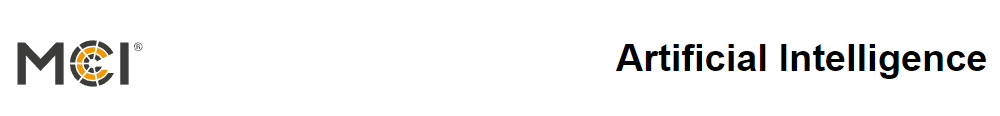

---

# 01 a Object Tracking with Lucas Kanade

Object tracking is a fundamental problem in computer vision that involves locating and following a specific object across consecutive video frames while maintaining its identity over time. It is widely used in applications such as surveillance, autonomous driving, and human–computer interaction. One of the classical approaches to tracking relies on motion estimation techniques like the Lucas–Kanade method, which tracks the movement of selected feature points on an object by estimating their displacement between frames. By applying Lucas–Kanade optical flow to these key points, a tracker can infer how the object moves and update its position frame by frame, making it a simple yet effective method for tracking objects in relatively stable and small-motion scenarios.

The Lucas–Kanade method relies on spatial intensity gradients, the method works best on textured regions where motion can be reliably detected. The algorithm is computationally efficient and is often applied in a sparse manner to selected feature points, making it useful for real-time applications such as video tracking and motion analysis.

In [1]:
# Import all packages needed in this notebook.
import numpy as np
import cv2 as cv
from PIL import Image
from matplotlib import pyplot as plt
import os
import glob
from scipy import signal
import shutil

# Optical Flow

To better understand how optical flow works, we just have a look on specific application for optical flow. At first we need to define a path to our test videos:

In [15]:
# feel free to choose the path to the video you want to use as example for the lecture. You can also use your own video, but make sure to change the path accordingly.

#path_Video = '../Data/Test_Videos/Climbing_Silence_1.mp4'
#path_Video = '../Data/Test_Videos/Climbing_Silence_2.mp4'
#path_Video = '../Data/Test_Videos/Heart_MRI_1.mp4'
#path_Video = '../Data/Test_Videos/Heart_MRI_2.mp4'
#path_Video = '../Data/Test_Videos/Heart_MRI_3.mp4'
#path_Video = '../Data/Test_Videos/Skateboarding_Hardflip.mp4'
path_Video = '../Data/Test_Videos/Skiing_Video.mp4'

In [17]:
def sparse_optical(path_Video):
    # Open video file
    cap = cv.VideoCapture(cv.samples.findFile(path_Video))
    no_Frames = int(cap.get(cv.CAP_PROP_FRAME_COUNT))
    print( 'Total number of frames is' , no_Frames )
    
    # Parameters for ShiTomasi corner detection
    feature_params = dict( maxCorners = 100, qualityLevel = 0.3, minDistance = 7, blockSize = 7 )
    color = np.random.randint(0, 255, (100, 3)) # Random colors for each point

    # Read first frame
    ret, old_frame = cap.read()
    prevImg = cv.cvtColor(old_frame, cv.COLOR_BGR2GRAY)
    good_Feture = cv.goodFeaturesToTrack(prevImg, mask = None, **feature_params)
    mask = np.zeros_like(old_frame)
    dt = 100
    
    # Lucas-Kanade parameters
    lk_params = dict(winSize=(15, 15), maxLevel=3, criteria=(cv.TERM_CRITERIA_EPS | cv.TERM_CRITERIA_COUNT, 10, 0.02))
    
    while(1):
        ret, frame = cap.read()
        if not ret:
            print('No frames grabbed!')
            break

        nextImg = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)
        
        # Apply Lucas-Kanade optical flow method
        p1, st, err = cv.calcOpticalFlowPyrLK(prevImg, nextImg, good_Feture, None, **lk_params)

        # Select good points
        if p1 is not None:
            good_new = p1[st==1]
            good_old = good_Feture[st==1]

        # Draw the tracks
        for i, (new, old) in enumerate(zip(good_new, good_old)):
            a, b = np.ravel(old)
            c, d = np.ravel(new)
            v_x = int((c - a)/dt)
            v_y = int((b - d)/dt)
            scale = 100
            v_x = int((c-a)/dt*scale)
            v_y = int((b-d)/dt*scale)

            mask = cv.arrowedLine(mask, (int(a),int(b)), (int(a)+v_x, int(b)+v_y), (255, 255, 255), 1)
        img = cv.add(frame, mask)

        cv.imshow('Result sparse optical flow', img)
        
        # Handle keypress for quitting the display window   
        k = cv.waitKey(30) & 0xff # Press 'ESC' to exit
        if k == 27:
            break
        
        # Update previous frame and points
        prevImg = nextImg.copy()
        good_Feture = good_new.reshape(-1, 1, 2)

    cv.destroyAllWindows()

sparse_optical(path_Video)

Total number of frames is 264
No frames grabbed!


As you can see the function *sparse_optical()* uses the Lucas Kanade Algorithms with specific parameters:

How do they work?
#### winSize 

- What it is: Spatial support (patch) over which LK minimizes the photometric error.
- Effects:
    - Robustness vs. detail: Larger windows average more pixels → more robust to noise and low-texture, but can blur across motion boundaries   and reduce sensitivity to small/local deformations.
    - Aperture problem: Small windows on edge-like regions give ill-conditioned systems; larger windows help by including more gradient diversity.
    - Convergence basin: Larger windows give a wider basin of attraction for the iterative solver (easier to converge on the right displacement).
    - Computational cost: Grows roughly with the number of pixels in the window (quadratically with window side).
- Practical picks:
    - Typical: 15×15 to 31×31 for tracking sparse features.
    - Use smaller windows for high-texture, fine details; larger for noisy or low-texture scenes.
    - If you see jitter or dropouts on low-texture features, increase winSize; if tracks “bleed” across object boundaries, decrease winSize.

#### maxLevel 

- What it is: How many extra coarser pyramid levels to use (level 0 is full resolution). A value of L means levels 0..L are used.
- Effects:
    - Handles large motion: Coarser levels see smaller apparent motion. With downsampling by ~2 per level, the maximum trackable displacement grows roughly exponentially with levels. Rule of thumb (with scale ≈ 2): Max recoverable displacement ≈ (winSize/2) × 2^L pixels at full resolution. Example: winSize=21, L=3 → ≈ 10 × 8 ≈ 80 px.
    - Stability: More levels can improve convergence for large inter-frame motion.
    - Cost: More levels increase runtime and may reduce precision slightly (due to repeated resampling).
- Practical picks:
    - 2–4 for typical video (25–60 FPS) with moderate motion.
    - Increase if you observe frequent lost tracks due to large jumps; decrease if motion is small and you want speed.
    - Ensure your features still exist at coarse scales (tiny features may vanish if too many levels are used).

#### criteria 

- What it is: Stopping rule for the per-level iterative refinement.
    - COUNT: Max number of Gauss–Newton iterations (e.g., 20–30).
    - EPS: Stop if the parameter update or the residual improvement is below ε (e.g., 0.01).
- Effects:
    - Accuracy vs. speed:
        - More iterations (higher COUNT) and tighter ε improve convergence and accuracy on difficult patches but increase runtime.
        - Too few iterations can leave under-converged estimates, causing drift or bias.
    - Noise sensitivity:
        - Very tight ε on noisy/low-texture patches can cause unnecessary iterations without real gains.
- Practical picks:
    - Common default: (COUNT|EPS, 30, 0.01).
    - If you need speed and motion is small/clean, try (COUNT|EPS, 10–15, 0.03–0.05).
    - If you see non-convergence on tough patches, increase COUNT to 30–50 and tighten ε to 0.005–0.01.



#### How they interact

Large motion requires either larger winSize or higher maxLevel (pyramids are usually the better solution). WinSize mostly improves stability and conditioning; maxLevel expands the motion range. Increasing both winSize and maxLevel increases compute significantly. Prefer raising maxLevel before greatly enlarging winSize. If you use large winSize, you may also need more iterations (criteria.COUNT) at each level to fully converge.
Texture matters: If the patch has poor gradients, no combination of parameters will help; use good features (e.g., Shi–Tomasi) or raise minEigThreshold.

#### Rules of thumb

Start: winSize ≈ 21×21, maxLevel ≈ 3, criteria ≈ (30, ε=0.01).
Fast/small motion: winSize 15×15, maxLevel 2, criteria (10–15, ε=0.03).
Large motion: keep winSize 21–31, raise maxLevel to 3–4; only bump winSize if convergence is unstable.
Motion near boundaries: prefer smaller winSize to avoid mixing foreground/background flow.
Validate conditioning: Reject tracks where the minimum eigenvalue of the 2×2 image Hessian within the window is too small (OpenCV’s minEigThreshold).

#### TASK:

Adapt the parameter of the Lukas Kanade algorithm to find an optimal solution for the video of your initial choice.
Redo the task for other viedos (feel free to choose from the existing test videos or choose your own)